# Fintech Retention Analysis

### 1. Retention & engagement diagnosis
- **H1**: Purchase **recency and frequency** in the observation window are the strongest predictors of whether a card churns in the outcome window — i.e., retention is driven more by *habit formation* than by transaction value.
- **H2**: Cards that go quiet for 30+ days have a materially lower probability of reactivating than cards with a shorter gap — establishing a "critical inactivity threshold" (this is the kind of number a lifecycle/marketing team would use to trigger a win-back campaign).
- **[Next Notebook] H3**: New cohorts (recent `first_active_month`) show a steeper early drop-off than older cohorts — an "onboarding/activation risk" story, directly relevant to a growth team worried about new-user retention curves. --> Tested on Fintech Cohort Analysis Notebook

- Define churn as 90+ days of inactivity per card_id

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt
%matplotlib inline

In [99]:
!pip list

Package                           Version
--------------------------------- ------------------
absl-py                           2.3.1
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
agate                             1.9.1
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.0
anaconda-proj

In [ ]:
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')

In [ ]:
new.head()

In [ ]:
print(f"Earliest date:", new['purchase_date'].min())
print(f"Latest date:", new['purchase_date'].max())

In [ ]:
historical.head()

In [ ]:
print(f"Earliest date:", historical['purchase_date'].min())
print(f"Latest date:", historical['purchase_date'].max())

In [ ]:
new['merchant_id'].value_counts()

In [ ]:
historical['merchant_id'].value_counts()

In [ ]:
# check the merchant_id in new but not in historical
# ~ means NOT
new_merchants = new.loc[
    ~new["merchant_id"].isin(historical["merchant_id"]),
    "merchant_id"
].unique()

In [ ]:
print(new_merchants)
print(f"merchant_id in historical:", len(historical["merchant_id"]))
print(f"merchant_id in new:", len(new["merchant_id"]))
print(f"merchant_id not in historical but in new:", len(new_merchants))

In [ ]:
# Concatenate two datasets
transactions = pd.concat(
    [historical, new],
    ignore_index=True
)

In [ ]:
transactions[:5]

In [ ]:
transactions.info()

In [ ]:
# change purchase_date to datetime
# add year and date
to_year = pd.to_datetime(transactions['purchase_date'])
transactions.loc[:,'year'] = to_year.dt.year
transactions.loc[:,'date'] = to_year.dt.date
transactions.info()

In [ ]:
print(f"Earliest date:", transactions['purchase_date'].min())
print(f"Latest date:",transactions['purchase_date'].max())

## H1: Recency and frequency predict churn
- H1: Purchase recency and frequency in the observation window are the strongest predictors of whether a card churns in the outcome window — i.e., retention is driven more by habit formation than by transaction value.

- In this project, I will define **"Churned"** as:
- **A card's last transaction occurs at least 90 days before the end of the observation period, with no subsequent transaction.**

#### Create a churn flag
**The Churn s defined here as follows:**
Observed churn: A card is classified as churned if its last observed transaction occurred at least 90 days before the end of the transaction observation period.

In [ ]:
# 1. Convert purchase_date
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])
transactions['purchase_date'].min(), transactions['purchase_date'].max()

In [ ]:
# 2. Define the observation end date
observation_end = transactions['purchase_date'].max()
print(f"Observation end date:", observation_end)

# Calculate the 90-day cutoff (=Churned)
churn_cutoff = observation_end - pd.Timedelta(days=90)
print(f"90-day cutoff (Churned):", churn_cutoff)

In [ ]:
# 3. Find the last transaction for each card
last_transaction = (
    transactions.groupby('card_id')['purchase_date']
      .max()
      .reset_index()
)

In [ ]:
# rename the columns
last_transaction = last_transaction.rename(
    columns={'purchase_date': 'last_purchase_date'}
)
last_transaction.head()

In [ ]:
# 4. Calculate days since last transaction
# Make the churn definition more transparent
last_transaction['days_since_last_purchase'] = (
    observation_end
    - last_transaction['last_purchase_date']
).dt.days
last_transaction.head()

In [ ]:
# plot the frequency of days since last purchase
last_transaction['days_since_last_purchase'].hist()
plt.show()

In [ ]:
# merge churn flags
transactions = pd.merge(transactions, last_transaction, on='card_id', how='outer')
transactions.head()

In [ ]:
# 5. Create the churn flag
last_transaction['churned_90d'] = (
    last_transaction['days_since_last_purchase'] >= 90
)
last_transaction['churned_90d'].value_counts()

### Create RFM Variables

In [ ]:
# Recency 
#Recency dataset
most_recent = transactions['date'].max()+dt.timedelta(days=1)
print(most_recent)

In [ ]:
Recency_filtered = transactions.groupby('card_id').date.agg(lambda x:(most_recent - x.max())).reset_index(name='recency')
print(Recency_filtered)

In [ ]:
# Frequency
#Frequency dataset
Frequency_filtered = transactions.groupby('card_id').purchase_date.count().reset_index(name='frequency')
Frequency_filtered.head()

In [ ]:
# Monetary values


In [ ]:
# merge Recency_filtered and Frequency_filtered to transactions dataset
transactions_rf = pd.merge(transactions, Frequency_filtered, on='card_id', how='outer')
transactions_rf = pd.merge(transactions_rf, Recency_filtered, on='card_id', how='outer')
# transactions = pd.merge(transactions, Monetary_filtered, on='card_id', how='outer')
transactions_rf.head()

In [ ]:
# Visualization
def f_and_r_scatter_plot(df):
    # convert recency to numeric
    df['recency_days'] = (
    df['recency']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
    )
    # basic scatterplot
    plt.figure(figsize=(10, 6))

    plt.scatter(
        df['recency_days'],
        df['frequency'],
        alpha=0.5
    )

    plt.xlabel('Recency (days)')
    plt.ylabel('Frequency (number of transactions)')
    plt.title('Recency vs. Frequency')
    
    plt.show()

f_and_r_scatter_plot(transactions_rf)

In [ ]:
# There are two outliers in Frequency so will exclude them and visualize again
transactions_rf_ex_outlier = transactions_rf[transactions_rf['frequency'] < 2500]
f_and_r_scatter_plot(transactions_rf_ex_outlier)

In [ ]:
#Assign RFM scores
#
recency_scores = range(5,0,-1)
frequency_scores = range(1,6)
# monetary_scores = range(1,6)

transactions_rf['r'] = pd.cut(transactions_rf['recency'], bins=5, labels = recency_scores)
transactions_rf['f'] = pd.cut(transactions_rf['frequency'], bins=5, labels = frequency_scores)
# rfm['m'] = pd.cut(rfm['monetary'], bins=5, labels = monetary_scores)

In [ ]:
# merge churn flags
transactions_rf = pd.merge(transactions_rf, last_transaction, on='card_id', how='outer')
transactions_rf.head()

In [ ]:
# Visualization
transactions_rf_ex_outlier= pd.merge(transactions_rf_ex_outlier, last_transaction, on='card_id', how='outer')
# Frequency vs Churn
groups = transactions_rf_ex_outlier["churned_90d"].unique()

for group in groups:
    plt.hist(
        transactions_rf_ex_outlier.loc[transactions_rf_ex_outlier["churned_90d"] == group, "frequency"],
        bins=30,
        alpha=0.5,
        label=group,
        density=True
    )

plt.xlabel("Frequency")
plt.ylabel("Number of cards")
plt.title("frequency Density Distribution by Churn")
plt.legend()
plt.show()

In [ ]:
# Recency vs Churn
groups = transactions_rf_ex_outlier["churned_90d"].unique()

for group in groups:
    plt.hist(
        transactions_rf_ex_outlier.loc[transactions_rf_ex_outlier["churned_90d"] == group, "recency_days"],
        bins=30,
        alpha=0.5,
        label=group,
        density=True
    )

plt.xlabel("Recency")
plt.ylabel("Number of cards")
plt.title("Recency Density Distribution by Churn")
plt.legend()
plt.show()


In [ ]:
# Define recency bins
bins = [0, 7, 14, 30, 60, 90, 120, 180, np.inf]

labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–60 days",
    "61–90 days",
    "91–120 days",
    "121–180 days",
    "180+ days"
]

transactions_rf["recency_bin"] = pd.cut(
    transactions_rf["recency_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

transactions_rf["frequency_bin"] = pd.cut(
    transactions_rf["frequency"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
# use last_transaction to use card_id level datasets
# merge recency_days column from transactions_rf
recency_days = transactions_rf[["card_id", "recency_days", "frequency", "recency_bin", "frequency_bin"]]
last_transaction = pd.merge(last_transaction, recency_days, on='card_id', how='left')

In [ ]:
last_transaction.head()

In [ ]:
# Define recency bins
bins = [0, 7, 14, 30, 60, 90, 120, 180, np.inf]

labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–60 days",
    "61–90 days",
    "91–120 days",
    "121–180 days",
    "180+ days"
]

last_transaction["recency_bin"] = pd.cut(
    last_transaction["recency_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bins_f = [0, 1, 2, 5, 10, 20, 50, np.inf]

labels_f = [
    "1",
    "2",
    "3–5",
    "6–10",
    "11–20",
    "21–50",
    "51+"
]

last_transaction["frequency_bin"] = pd.cut(
    last_transaction["frequency"],
    bins=bins_f,
    labels=labels_f,
    include_lowest=True
)

In [ ]:
transactions_rf["recency_days"].describe().round(2)

In [ ]:
last_transaction.head()

In [ ]:
recency_analysis = (
    last_transaction.groupby("recency_bin", observed=False)
      .agg(
          customers=("card_id", "nunique"),
          churned=("churned_90d", "sum")
      )
      .reset_index()
)

# Return rate
recency_analysis["churn_rate"] = (
    recency_analysis["churned"]
    / recency_analysis["customers"]
)

# Churn rate
recency_analysis["return_rate"] = (
    1 - recency_analysis["churn_rate"]
)

recency_analysis

In [ ]:
frequency_analysis = (
    last_transaction.groupby("frequency_bin", observed=False)
      .agg(
          customers=("card_id", "nunique"),
          churned=("churned_90d", "sum")
      )
      .reset_index()
)

# Return rate
frequency_analysis["churn_rate"] = (
    frequency_analysis["churned"]
    / frequency_analysis["customers"]
)

# Churn rate
frequency_analysis["return_rate"] = (
    1 - frequency_analysis["churn_rate"]
)

frequency_analysis

In [ ]:
# Recency vs Churn plot
# Convert return rate to percentage
plot_df = recency_analysis.copy()
plot_df["churn_rate_pct"] = plot_df["churn_rate"]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["recency_bin"].astype(str),
    plot_df["churn_rate_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel("Days since last purchase")
plt.ylabel("Churn probability (%)")
plt.title("Churn Probability by Recency")
plt.ylim(0, 100)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Frequency vs Churn plot
# Convert return rate to percentage
plot_df_f = frequency_analysis.copy()
plot_df_f["churn_rate_pct"] = plot_df_f["churn_rate"]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    plot_df_f["frequency_bin"].astype(str),
    plot_df_f["churn_rate_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel("Frequency")
plt.ylabel("Churn probability (%)")
plt.title("Churn Probability by Frequency")
plt.ylim(0, 100)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Correlation analysis (Pearson + Spearman)
for var in ["frequency", "recency_days"]:
    pearson_r, pearson_p = stats.pearsonr(last_transaction[var], last_transaction['churned_90d'])
    spearman_r, spearman_p = stats.spearmanr(last_transaction[var], last_transaction['churned_90d'])
    print(f"\n{var} vs churn:")
    print(f"  Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.5g})")
    print(f"  Spearman r = {spearman_r:.3f}  (p = {spearman_p:.5g})")

# H2: 30+ day inactivity threshold
H2: Cards that go quiet for 30+ days have a lower probability of reactivating than cards with a shorter gap — establishing a "critical inactivity threshold" (this is the kind of number a lifecycle/marketing team would use to trigger a win-back campaign).

### Flag cards with a 30+ day gap & the Reactivated status
**Definition of Reactivated:** “Did this card make another purchase after this purchase?”
1. Create every **consecutive transaction gap** for each card_id.
2. Identify whether each gap is **completed (the next transaction is observed)** or **right-censored (the transaction is the last observed transaction for that card)**.

**Difference between 'Churn'**
- Here, Churn is defined as: churned if its last observed transaction occurred at least 90 days before the end of the transaction observation period.

In [ ]:
def flag_reactivate(df):
    # 1. Prepare transaction data
    df["purchase_date"] = pd.to_datetime(df["purchase_date"])

    # Sort chronologically within each card
    df = df.sort_values(
        ["card_id", "purchase_date"]
    ).reset_index(drop=True)

    # 2. Define previous and next transaction
    # previous purchase date
    df["prev_purchase_date"] = (
        df.groupby("card_id")["purchase_date"]
          .shift(1)
    )
    # next purchae date
    df["next_purchase_date"] = (
        df.groupby("card_id")["purchase_date"]
          .shift(-1)
    )
    # 3. Define the observation end date
    observation_end = df["purchase_date"].max()
    
    print("Observation end:", observation_end)

    # 4. Calculate the gap to the next transaction
    df["gap_days"] = (
        df["next_purchase_date"] - df["purchase_date"]
    ).dt.total_seconds() / (60 * 60 * 24)

    # 5. Identify completed vs right-censored episodes
    # A completed gap has a subsequent transaction
    df["completed_gap"] = df["next_purchase_date"].notna()

    # A right-censored episode is the last observed transaction
    df["right_censored"] = df["next_purchase_date"].isna()

    # 6. For censored observations, calculate observed
    #  follow-up time until the dataset ends
        # IF customer purchased again: followup_days = days until their next purchase
        # ELSE: followup_days = days from their purchase until the dataset ended
    df["followup_days"] = np.where(
        df["completed_gap"],
        df["gap_days"],
        (
            observation_end - df["purchase_date"]
        ).dt.total_seconds() / (60 * 60 * 24)
    )

    # 7. Define reactivation
    # Reactivated = a subsequent transaction was observed
    df["reactivated"] = df["completed_gap"].astype(int)

    return df

### Create columns
#### 3 Newly Created Columns

| Column | What it represents |
|---|---|
| `prev_purchase_date` | The previous transaction date for the same card. |
| `next_purchase_date` | The next transaction date for the same card. |
| `gap_days` | The number of days between the current transaction and the next transaction. |
| `completed_gap` | Indicates whether a subsequent transaction was observed for the card. |
| `right_censored` | Indicates that no subsequent transaction was observed before the end of the observation period. |
| `followup_days` | The number of days the card was observed after the current transaction. For reactivated cards, this is the time until reactivation; for right-censored cards, this is the time until the observation period ended. |
| `reactivated` | Indicates whether the card had a subsequent transaction: `1` = reactivated, `0` = not observed to reactivate. |

In [ ]:
transactions = flag_reactivate(transactions)
transactions.head()

In [ ]:
transactions[['completed_gap','right_censored']].value_counts()

--> 'completed_gap'and'right_censored' are consistent

In [ ]:
columns = ["gap_days", "completed_gap","right_censored","followup_days", "reactivated"]
transactions[columns].describe().round(2)

In [ ]:
# plot gap_days
plt.figure(figsize=(10, 6))

plt.hist(
    transactions["gap_days"].dropna(),
    bins=50
)

plt.axvline(
    10,
    linestyle="--",
    linewidth=2,
    label="10-day threshold"
)

plt.xlabel("Gap between purchases (days)")
plt.ylabel("Number of transactions")
plt.title("Distribution of Purchase Gaps")
plt.legend()

plt.show()

In [ ]:
# Plot followup_days
plt.figure(figsize=(10, 6))

plt.hist(
    transactions["followup_days"].dropna(),
    bins=50
)

plt.axvline(
    10,
    linestyle="--",
    linewidth=2,
    label="10-day threshold"
)

plt.xlabel("followup_days between purchases (days)")
plt.ylabel("Number of transactions")
plt.title("Distribution of Purchase Gaps (Followup Days)")
plt.legend()

plt.show()

In [ ]:
transactions.groupby('reactivated').followup_days.mean()

In [ ]:
bins = [
    0,
    1,
    3,
    7,
    14,
    21,
    30,
    45,
    60,
    90,
    180,
    np.inf
]

labels = [
    "0–1",
    "1–3",
    "3–7",
    "7–14",
    "14–21",
    "21–30",
    "30–45",
    "45–60",
    "60–90",
    "90–180",
    "180+"
]

transactions["inactivity_bin"] = pd.cut(
    transactions["followup_days"],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
summary = (
    transactions
    .groupby("inactivity_bin", observed=True)
    .agg(
        n=("reactivated", "size"),
        reactivated=("reactivated", "sum"),
        reactivation_rate=("reactivated", "mean")
    )
    .reset_index()
)

summary

In [ ]:
# Visualization
# Followup_days vs Reactivation
groups_r = transactions["reactivated"].unique()

for group in groups_r:
    plt.hist(
        transactions.loc[transactions["reactivated"] == group, "followup_days"],
        bins=30,
        alpha=0.5,
        label=group,
        density=True
    )

plt.xlabel("followup_days (The number of days the card was observed after the current transaction.")
plt.ylabel("Number of cards")
plt.title("frequency Density Distribution by Reactivation")
plt.legend()
plt.show()

In [67]:
groups_r

array([1, 0])

In [68]:
transactions['gap_days'].describe()

count    3.074985e+07
mean     3.115625e+00
std      8.745752e+00
min      0.000000e+00
25%      7.474537e-02
50%      7.479977e-01
75%      2.231007e+00
max      3.802297e+02
Name: gap_days, dtype: float64

In [69]:
transactions["gap_days"].describe().round(0)

count    30749852.0
mean            3.0
std             9.0
min             0.0
25%             0.0
50%             1.0
75%             2.0
max           380.0
Name: gap_days, dtype: float64

In [70]:
transactions[["reactivated", "followup_days"]].isna().sum()

reactivated      0
followup_days    0
dtype: int64

In [71]:
transactions["gap_days"].unique()

array([ 0.0743287 ,  1.99320602,  3.86184028, ..., 22.45466435,
       13.37171296,  7.43166667])

In [72]:
# Drop the NaN values from "gap_days"
# Null values are there when the end date is not speified whithin the timeframe of the dataset
# Drop rows where gap_days is NaN
transactions_notna = transactions[
    transactions["gap_days"].notna()
].copy()

transactions_notna.shape

(30749852, 26)

In [73]:
transactions_notna['reactivated'].value_counts()

reactivated
1    30749852
Name: count, dtype: int64

### Survival Analysis

In [75]:
from lifelines import KaplanMeierFitter, NelsonAalenFitter

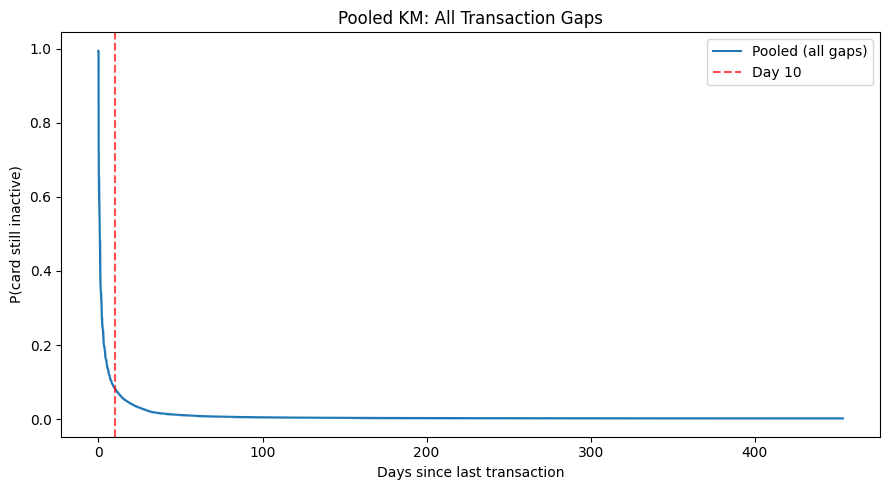

In [76]:
# POOLED KM (for ALL gap-rows, as-is)
kmf_pooled = KaplanMeierFitter()
kmf_pooled.fit(
    durations=transactions["followup_days"],
    event_observed=transactions["reactivated"],
    label="Pooled (all gaps)"
)
 
plt.figure(figsize=(9, 5))
kmf_pooled.plot_survival_function(ci_show=True)
plt.axvline(10, color="red", linestyle="--", alpha=0.7, label="Day 10")
plt.xlabel("Days since last transaction")
plt.ylabel("P(card still inactive)")
plt.title("Pooled KM: All Transaction Gaps")
plt.legend()
plt.tight_layout()
plt.savefig("km_pooled.png", dpi=150)
plt.show()

--> the size of the step reflects how many cards reactivated at that time, relative to how many were still "at risk" (still inactive) up to that point.
- Day-10 reference line: Where the curve crosses x = 10, the y-value tells you the estimated probability a card is still inactive at day 10 given it was inactive at day 0. 

**Landmark/conditional survival:** Cards still inactive at day 10 reactivate slower than cards inactive at day 5 — and day 30 is checked as a further point to see if the effect keeps compounding. = *The longer a card stays inactive, the less likely it is to come back.*
- **Question:** given a card is still inactive 10 days after its last transaction, how much longer until it reactivates?

In [78]:
# Single point estimate at day 10
prob_inactive_day10 = kmf_pooled.survival_function_at_times(10).values[0]
print(f"P(still inactive at day 10): {prob_inactive_day10:.3f}")
print(f"P(reactivated by day 10): {1 - prob_inactive_day10:.3f}")

P(still inactive at day 10): 0.082
P(reactivated by day 10): 0.918


In [79]:
# Single point estimate at day 5
prob_inactive_day5 = kmf_pooled.survival_function_at_times(5).values[0]
print(f"P(still inactive at day 5): {prob_inactive_day5:.3f}")
print(f"P(reactivated by day 5): {1 - prob_inactive_day5:.3f}")

P(still inactive at day 5): 0.148
P(reactivated by day 5): 0.852


In [80]:
def perform_kmf(transactions_df, landmark_time):
    # 1. select gaps that survived to the landmark
    mask = transactions_df['followup_days'] >= landmark_time
    landmark_df = transactions_df[mask].copy()
    
    # 2. re-baseline the time since the landmark, not since original transaction
    landmark_df['time_since_landmark'] = landmark_df['followup_days'] - landmark_time

    # 3. Landmark KM: cards that survived to the landmark_time, curb re-baselined to t=0 at day 10
    kmf_landmark = KaplanMeierFitter()

    kmf_landmark.fit(
        durations=landmark_df['time_since_landmark'],   # <- re-baselined, not followup_days
        event_observed=landmark_df['reactivated'],
        label=f'Landmark day {landmark_time} (n={len(landmark_df)})'
        )
    
    plt.figure(figsize=(9, 5))
    kmf_landmark.plot_survival_function(ci_show=True)
    plt.xlabel(f"Days since day-{landmark_time} landmark")
    plt.ylabel(f'P(card still inactive, given inactive at day {landmark_time})')
    plt.title(f'Landmark KM: Reactivation Given Survival to Day {landmark_time}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'km_landmark{landmark_time} .png', dpi=150)
    plt.show()

    return kmf_landmark

In [81]:
def kmp_reactivation_table(kmf, days):
    survival = kmf.predict(days)
    # Get the KM confidence interval table
    ci = kmf.confidence_interval_
    # Find the time point closest to `days`
    idx = ci.index[ci.index <= days][-1]
    lower = ci.loc[idx].iloc[0]   # survival lower bound at that day
    upper = ci.loc[idx].iloc[1]   # survival upper bound at that day
    
    return {
        'survival (still inactive)': survival.round(4),
        'reactivation': (1 - survival).round(4),
        'reactivation_lower': (1 - upper).round(4),
        'reactivation_upper': (1 - lower).round(4)}

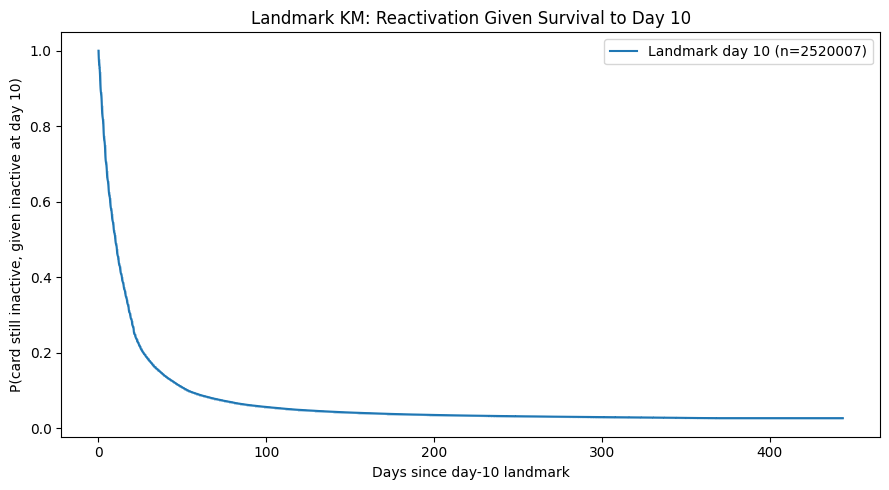

<lifelines.KaplanMeierFitter:"Landmark day 10 (n=2520007)", fitted with 2.52001e+06 total observations, 228465 right-censored observations>

In [82]:
# LANDMARK KM: cards that survived to day 10, curve re-baselined to t=0 at day 10
kmf_10 = perform_kmf(transactions, 10)
kmf_10

In [83]:
kmp_reactivation_table(kmf_10, 30)

{'survival (still inactive)': 0.1804,
 'reactivation': 0.8196,
 'reactivation_lower': 0.8192,
 'reactivation_upper': 0.8201}

--> Among Day-10 survivors, 18.0% of the cards remain inactive while 82.0 get reactivaed 

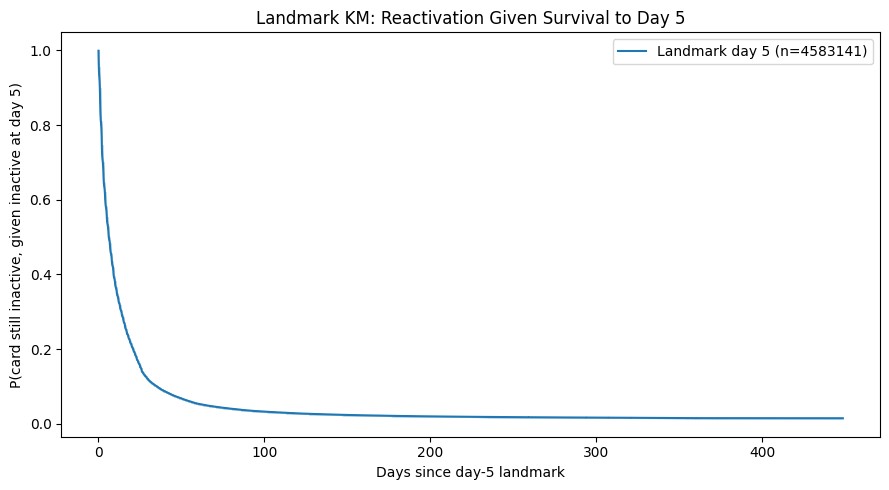

<lifelines.KaplanMeierFitter:"Landmark day 5 (n=4583141)", fitted with 4.58314e+06 total observations, 260195 right-censored observations>

In [85]:
# LANDMARK KM: cards that survived to day 5, curve re-baselined to t=0 at day 5
kmf_5 = perform_kmf(transactions, 5)
kmf_5

In [86]:
kmp_reactivation_table(kmf_5, 30)

{'survival (still inactive)': 0.1181,
 'reactivation': 0.8819,
 'reactivation_lower': 0.8816,
 'reactivation_upper': 0.8822}

--> Among Day-5 survivors, 11.8% of the cards remain inactive while 88.2% get reactivaed

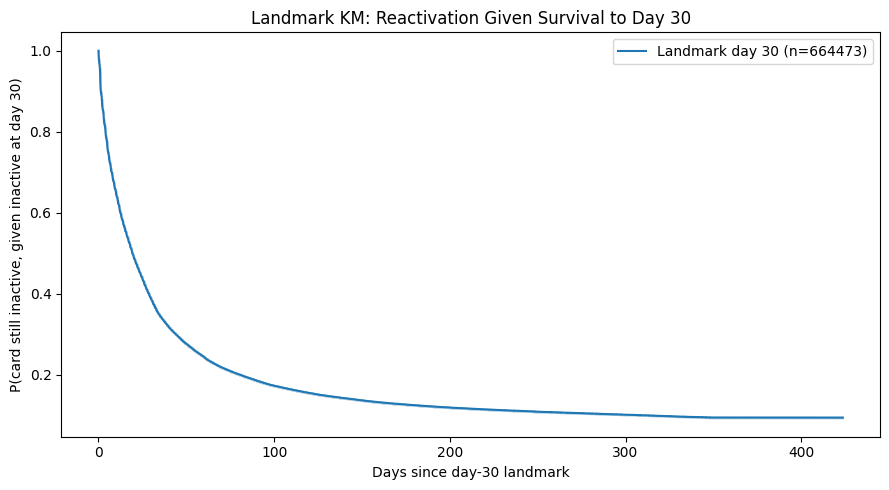

<lifelines.KaplanMeierFitter:"Landmark day 30 (n=664473)", fitted with 664473 total observations, 157683 right-censored observations>

In [88]:
# LANDMARK KM: cards that survived to day 30, curve re-baselined to t=0 at day 30
kmf_30 = perform_kmf(transactions, 30)
kmf_30

In [89]:
kmp_reactivation_table(kmf_30, 30)

{'survival (still inactive)': 0.3867,
 'reactivation': 0.6133,
 'reactivation_lower': 0.6121,
 'reactivation_upper': 0.6146}

--> Among Day-30 survivors, 38.8.0% of the cards remain inactive while 61.3% get reactivaed

In [91]:
# survival in 5 day horizon for each landmark day
common_horizon = 5

result_5  = kmp_reactivation_table(kmf_5, common_horizon)
result_10 = kmp_reactivation_table(kmf_10, common_horizon)
result_30 = kmp_reactivation_table(kmf_30, common_horizon)

print("Landmark day 5, +5d:", result_5)
print("Landmark day 10, +5d:", result_10)
print("Landmark day 30, +5d:", result_30)

Landmark day 5, +5d: {'survival (still inactive)': 0.5549, 'reactivation': 0.4451, 'reactivation_lower': 0.4446, 'reactivation_upper': 0.4455}
Landmark day 10, +5d: {'survival (still inactive)': 0.6775, 'reactivation': 0.3225, 'reactivation_lower': 0.3219, 'reactivation_upper': 0.3231}
Landmark day 30, +5d: {'survival (still inactive)': 0.765, 'reactivation': 0.235, 'reactivation_lower': 0.234, 'reactivation_upper': 0.2361}


### Logrank test
-> checking whether cards that were already quiet for 30 days come back at a different pace than cards that were only quiet for 5 days, once you start the clock at each group's own landmark.

In [93]:
from lifelines.statistics import logrank_test

results = logrank_test(
    landmark_df_5['t_since_landmark'], landmark_df_30['t_since_landmark'],
    event_observed_A=landmark_df_5['reactivated'], event_observed_B=landmark_df_30['reactivated']
)
results.print_summary()

NameError: name 'landmark_df_5' is not defined

In [ ]:
# save to csv
transactions.to_csv("transactions.csv", index=False)